 # TODO
 -  Anomaly Detectio
- error_group повний аналіз
- card_mask_hash unique cards per user
- Geographic mismatches (card_country vs reg_country vs payment_country)
- status fail rate per user
- card_holder vs email name matching
- transaction_type distribution per fraud class
- Amount distribution (log-scale, характерні суми)
- Time gap: registration → first transaction
- оформити список користних фіч та їх коіфіціенти
 
15.03
-  Bayesian smoothing для Fraud rate по країнах
- додати булеві занчення, по тому чи reg_country  == card_country  == payment_country, reg_country == card_country, payment_country == card_country
- fail_status_coefficient  дає імпакт
- додати койфіціент по кожній з error_group
- country_CP_missmatch_coef дає хороший імпакт
- unique_cards_per_user має великий імпакт до is_fraud


**ідеї для feature engineering**
- розбити пошти на категорії по доменам
- додати ознаки чи транзакція вночі чи вдень
- порівнювати card_holder з оригінальним юзер емейлом та з гендером

# Feature Impact Summary

## Числові фічі (AUC + Point-Biserial)

| # | Feature | AUC | Corr | p-value | Сила | Тип |
|---|---------|-----|------|---------|------|-----|
| 1 | unique_card_holders | **0.8035** | 0.3249 | 0.00e+00 | Відмінна | diversity |
| 2 | unique_error_types | **0.8025** | 0.2836 | 0.00e+00 | Відмінна | diversity |
| 3 | unique_cards_per_user | **0.7967** | 0.2896 | 0.00e+00 | Відмінна | diversity |
| 4 | tx_count | **0.7292** | 0.1207 | 0.00e+00 | Добра | volume |
| 5 | fail_status_coefficient | **0.7141** | 0.1511 | 0.00e+00 | Добра | error |
| 6 | amount_sum | 0.6956 | 0.1019 | 0.00e+00 | Помірна | amount |
| 7 | country_CP_mismatch_coef | 0.6633 | 0.1524 | 0.00e+00 | Помірна | geo mismatch |
| 8 | country_CReg_mismatch | 0.6434 | 0.1622 | 0.00e+00 | Помірна | geo mismatch |
| 9 | fraud_error_count | 0.6308 | 0.1327 | 0.00e+00 | Помірна | error |
| 10 | fraud_error_rate | 0.6163 | 0.0626 | 0.00e+00 | Слабка+ | error |
| 11 | amount_range | 0.5637 | 0.0872 | 0.00e+00 | Слабка | amount |
| 12 | amount_std | 0.5557 | 0.0467 | 4.45e-190 | Слабка | amount |
| 13 | amount_cv | 0.5545 | 0.0447 | 1.10e-173 | Слабка | amount |
| 14 | time_to_first_transaction | 0.5537 | -0.0168 | 4.01e-26 | Слабка | temporal |
| 15 | name_in_email | 0.5499 | -0.0413 | 1.12e-148 | Слабка | identity |
| 16 | unique_card_countries | 0.5493 | 0.1266 | 0.00e+00 | Слабка | diversity |
| 17 | tx_type_resign_rate | 0.5422 | 0.0382 | 6.76e-128 | Слабка | tx type |
| 18 | cvv_error_coef | 0.5302 | 0.0007 | 6.72e-01 | Шум | error |
| 19 | amount_max | 0.5296 | 0.0836 | 0.00e+00 | Шум | amount |
| 20 | amount_mean | 0.5161 | 0.0428 | 8.67e-160 | Шум | amount |
| 21 | reg_is_night | 0.5018 | -0.0015 | 3.46e-01 | Шум | temporal |
| 22 | reg_hour | 0.5016 | -0.0010 | 5.37e-01 | Шум | temporal |

## Бінарні фічі (Phi Coefficient)

| # | Feature | Phi (φ) | p-value | Сила |
|---|---------|---------|---------|------|
| 1 | is_cvv_error | 0.0256 | 3.75e-58 | Дуже слабка |

## Категоріальні фічі (Theil's U → is_fraud)

| # | Feature | Theil's U | Сила |
|---|---------|-----------|------|
| 1 | card_country | 0.0251 | Помірна |
| 2 | payment_country | 0.0241 | Помірна |
| 3 | reg_country | 0.0240 | Помірна |
| 4 | gender | 0.0175 | Слабка |
| 5 | status | 0.0117 | Слабка |
| 6 | traffic_type | 0.0087 | Слабка |
| 7 | card_type | 0.0051 | Дуже слабка |
| 8 | domain | 0.0046 | Дуже слабка |
| 9 | currency | 0.0040 | Дуже слабка |
| 10 | transaction_type | 0.0034 | Дуже слабка |
| 11 | card_brand | 0.0029 | Дуже слабка |

## Шкала оцінки

**AUC:** 0.80+ = відмінна, 0.70–0.80 = добра, 0.60–0.70 = помірна, 0.55–0.60 = слабка, <0.55 = шум

**Theil's U:** >0.02 = помірна, 0.01–0.02 = слабка, <0.01 = дуже слабка

**Phi (φ):** >0.1 = помірна, 0.03–0.1 = слабка, <0.03 = дуже слабка

#Setup

## Imports

In [ ]:
!pip install umap-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency
import seaborn as sns
from sklearn.preprocessing import TargetEncoder
import umap
from sklearn.metrics import roc_auc_score
from scipy.stats import pointbiserialr
from sklearn.metrics import roc_auc_score
from scipy.stats import pointbiserialr
from scipy.stats import pearsonr

## Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Config

In [ ]:
root_path = "/content/drive/MyDrive/raw_data"
train_user_data_path = root_path + "/train_users.csv"
train_transaction_data_path = root_path + "/train_transactions.csv"

# Data Loading

In [ ]:
df_user = pd.read_csv(train_user_data_path)
df_transaction =  pd.read_csv(train_transaction_data_path)

# EDA — User Data

## Overview

In [ ]:
df_user

,id_user,timestamp_reg,email,gender,reg_country,traffic_type,is_fraud
0,15383249,2025-07-16 19:01:23.868869+00:00,larsjohansson@gmail.com,male,Sweden,cpa,0
1,9458117,2025-05-04 19:30:02.902877+00:00,evamark@yahoo.com,male,Romania,cpa,0
2,21312302,2025-09-07 18:24:51+00:00,stmark86@gmail.com,male,Austria,ppc,0
3,61828,2025-01-01 17:33:08.026088+00:00,robertwalker@gmail.com,male,Portugal,organic,1
4,13164211,2025-06-21 18:27:03.420098+00:00,sarah.miller@gmail.com,female,Belgium,organic,0
...,...,...,...,...,...,...,...
395376,15208750,2025-07-15 00:09:30.100536+00:00,alexpaterson@gmail.com,male,United States,cpa,0
395377,34511422,2025-12-22 16:25:42+00:00,kmiller216@gmail.com,male,United States,ppc,0
395378,28313259,2025-11-04 17:41:08+00:00,vams25@gmail.com,male,United States,ppc,0
395379,31685096,2025-12-01 15:28:38+00:00,lrwinpdx@gmail.com,female,United States,ppc,0


In [ ]:
df_transaction

,id_user,timestamp_tr,amount,status,transaction_type,error_group,currency,card_brand,card_type,card_country,card_holder,card_mask_hash,payment_country
0,15383249,2025-09-06 07:45:39+00:00,3.81,fail,card_recurring,antifraud,EUR,MASTERCARD,DEBIT,Sweden,johansson lars,24fe124163d8a8fd,Sweden
1,9458117,2025-10-10 11:23:30+00:00,7.94,success,card_init,NaN,EUR,VISA,DEBIT,Romania,mark evans,c363e0db18c5eca8,Romania
2,21312302,2025-09-07 19:48:45+00:00,3.81,success,card_recurring,NaN,EUR,MASTERCARD,DEBIT,Austria,mark stevens,553fa6ecd2fef3a7,Austria
3,61828,2025-01-02 10:25:02.150802+00:00,3.48,fail,card_init,antifraud,EUR,VISA,DEBIT,Portugal,felipe felipe,83717e93d7e75536,Portugal
4,13164211,2025-12-23 21:56:32+00:00,29.25,success,card_recurring,NaN,EUR,MASTERCARD,CREDIT,Belgium,sarah miller,d46d8d6af130a374,United States
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135373,30507985,2025-12-08 05:35:07+00:00,8.95,success,card_recurring,NaN,USD,MASTERCARD,DEBIT,United States,gregory vane,f8fb133fc1cb8e07,United States
3135374,12584522,2025-07-16 15:17:25+00:00,21.00,success,card_recurring,NaN,USD,VISA,DEBIT,United States,felicity harrison,0c77ad1169ca45e2,Philippines
3135375,13612852,2025-08-05 03:30:11+00:00,21.00,fail,card_recurring,fraud,USD,VISA,DEBIT,United States,arthur m bennett,0923a167cae6017b,United States
3135376,5752365,2025-03-21 08:21:55+00:00,3.00,success,card_recurring,NaN,USD,VISA,DEBIT,United States,robert carter,8821518cda8a979e,Ukraine


## Class Balance

In [ ]:
cnt_froud = df_user[df_user['is_fraud'] == 1]['is_fraud'].count()
cnt_user = df_user.shape[0]
fraud_percentage = (cnt_froud / cnt_user ) *100

print(f"number of user: {cnt_user}")
print(f"number of froud user: {cnt_froud}")
print(f"fraud percentage: {fraud_percentage:.5}%")

number of user: 395381
number of froud user: 14932
fraud percentage: 3.7766%


<Axes: xlabel='is_fraud'>

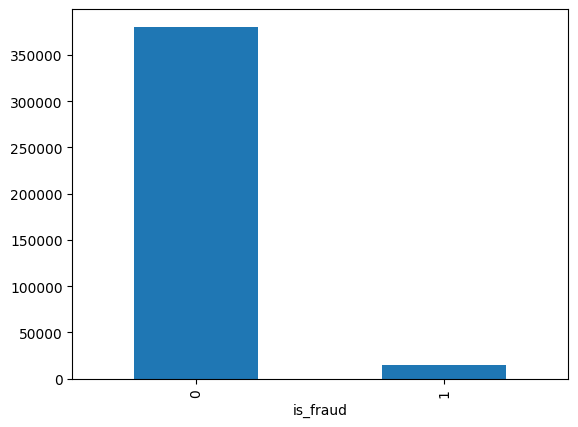

In [ ]:
df_user['is_fraud'].value_counts().plot(kind='bar')

## Schema & Missing Values

In [ ]:
df_user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395381 entries, 0 to 395380
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id_user        395381 non-null  int64 
 1   timestamp_reg  395381 non-null  object
 2   email          395063 non-null  object
 3   gender         395381 non-null  object
 4   reg_country    395255 non-null  object
 5   traffic_type   395381 non-null  object
 6   is_fraud       395381 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 21.1+ MB


In [ ]:
df_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3135378 entries, 0 to 3135377
Data columns (total 13 columns):
 #   Column            Dtype  
---  ------            -----  
 0   id_user           int64  
 1   timestamp_tr      object 
 2   amount            float64
 3   status            object 
 4   transaction_type  object 
 5   error_group       object 
 6   currency          object 
 7   card_brand        object 
 8   card_type         object 
 9   card_country      object 
 10  card_holder       object 
 11  card_mask_hash    object 
 12  payment_country   object 
dtypes: float64(1), int64(1), object(11)
memory usage: 311.0+ MB


## Categorical Features — Fraud Rate

### domain extraction + analysis

In [ ]:
df_user['email'].dropna().apply(lambda x: x.split('@')[1]).unique()

array(['gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com'],
      dtype=object)

In [ ]:
df_user['domain'] = df_user['email'].apply(lambda x: x.split('@')[1] if pd.notna(x) else 'missing')
df_user

,id_user,timestamp_reg,email,gender,reg_country,traffic_type,is_fraud,domain
0,15383249,2025-07-16 19:01:23.868869+00:00,larsjohansson@gmail.com,male,Sweden,cpa,0,gmail.com
1,9458117,2025-05-04 19:30:02.902877+00:00,evamark@yahoo.com,male,Romania,cpa,0,yahoo.com
2,21312302,2025-09-07 18:24:51+00:00,stmark86@gmail.com,male,Austria,ppc,0,gmail.com
3,61828,2025-01-01 17:33:08.026088+00:00,robertwalker@gmail.com,male,Portugal,organic,1,gmail.com
4,13164211,2025-06-21 18:27:03.420098+00:00,sarah.miller@gmail.com,female,Belgium,organic,0,gmail.com
...,...,...,...,...,...,...,...,...
395376,15208750,2025-07-15 00:09:30.100536+00:00,alexpaterson@gmail.com,male,United States,cpa,0,gmail.com
395377,34511422,2025-12-22 16:25:42+00:00,kmiller216@gmail.com,male,United States,ppc,0,gmail.com
395378,28313259,2025-11-04 17:41:08+00:00,vams25@gmail.com,male,United States,ppc,0,gmail.com
395379,31685096,2025-12-01 15:28:38+00:00,lrwinpdx@gmail.com,female,United States,ppc,0,gmail.com


In [ ]:
fraud_by_domain = df_user[df_user['is_fraud'] == 1].groupby('domain')['is_fraud'].count().reset_index()
fraud_by_domain.columns = ['domain', 'fraud_count']
display(fraud_by_domain.sort_values(by='fraud_count', ascending=False))

,domain,fraud_count
0,gmail.com,13082
4,yahoo.com,1110
1,hotmail.com,441
3,outlook.com,272
2,missing,27


In [ ]:
total_users_by_domain = df_user.groupby('domain').size().reset_index(name='total_users')
domain_fraud_percentage = pd.merge(fraud_by_domain, total_users_by_domain, on='domain', how='left')
domain_fraud_percentage['fraud_percentage'] = (domain_fraud_percentage['fraud_count'] / domain_fraud_percentage['total_users']) * 100
display(domain_fraud_percentage.sort_values(by='fraud_percentage', ascending=False))

,domain,fraud_count,total_users,fraud_percentage
2,missing,27,318,8.490566
3,outlook.com,272,5552,4.899135
0,gmail.com,13082,341532,3.830388
4,yahoo.com,1110,33702,3.293573
1,hotmail.com,441,14277,3.088884


### fraud rate by cat_columns

In [ ]:
cat_columns = df_user.select_dtypes(include='object').columns.tolist()
cat_columns = [col for col in cat_columns if col not in ['timestamp_reg', 'email']]
print(cat_columns)

['gender', 'reg_country', 'traffic_type', 'domain']


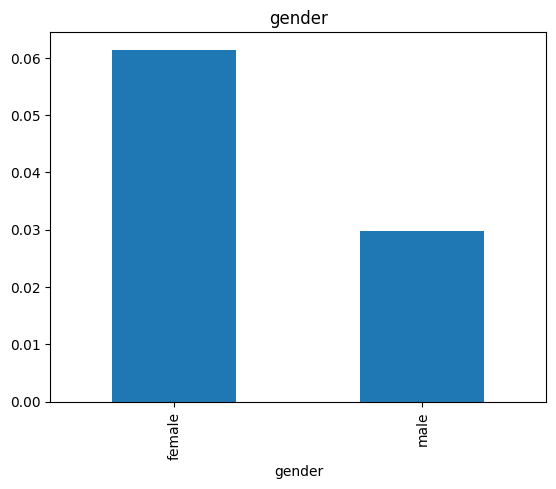

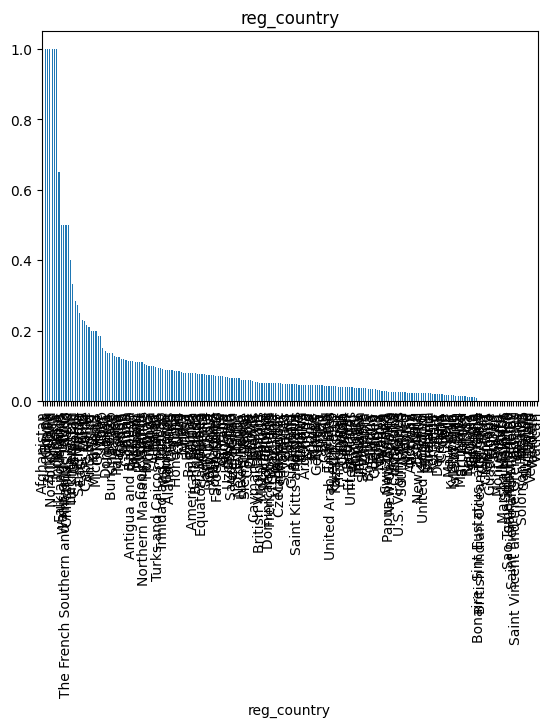

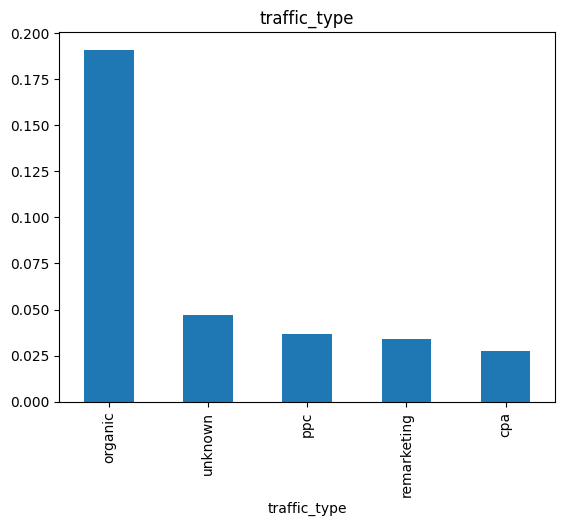

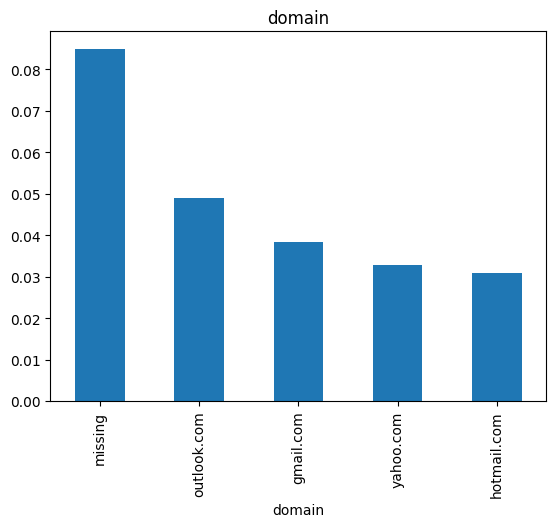

In [ ]:
for col in cat_columns:
  fraud_rate = df_user.groupby(col)['is_fraud'].mean().sort_values(ascending=False)
  fraud_rate.plot(kind='bar', title=f'{col}')
  plt.show()

### fraud rate by reg_country

In [ ]:
fraud_rate_bt_reg_country = df_user.groupby('reg_country')['is_fraud'].mean().sort_values(ascending=False)

In [ ]:
fraud_rate_bt_reg_country.head(10)

,is_fraud
reg_country,
Afghanistan,1.00
Egypt,1.00
Ghana,1.00
Zimbabwe,1.00
Norfolk Island,1.00
Nigeria,1.00
Indonesia,1.00
Ukraine,0.65
Falkland Islands,0.50


In [ ]:
mean_user_per_country = df_user['reg_country'].value_counts().mean()
print(f"mean user per country:  {mean_user_per_country}")

mean user per country:  1838.3953488372092


In [ ]:
fraud_rate_bt_reg_country[df_user['reg_country'].value_counts() >= 1800]

,is_fraud
reg_country,
Netherlands,0.064410
Argentina,0.046056
France,0.045092
Germany,0.044794
Brazil,0.044494
Canada,0.040064
United States,0.038850
Kenya,0.028978
South Africa,0.025334


In [ ]:
fraud_rate_bt_reg_country[df_user['reg_country'].value_counts() < 1800]

,is_fraud
reg_country,
Afghanistan,1.0
Egypt,1.0
Ghana,1.0
Zimbabwe,1.0
Norfolk Island,1.0
...,...
Suriname,0.0
Tuvalu,0.0
Venezuela,0.0


###  Chi-Squared tests

In [ ]:
print("chi2 — сила відхилення від 'незалежності'. Чим більше — тим сильніший зв'язок")
print("p-value < 0.05 — зв'язок не випадковий (відкидаємо H₀ про незалежність)\n")
for col in cat_columns:
    contingency = pd.crosstab(df_user[col], df_user['is_fraud'])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    print(f"{col}: chi2={chi2:.2f}, p-value={p_value:.6f}")

chi2 — сила відхилення від 'незалежності'. Чим більше — тим сильніший зв'язок
p-value < 0.05 — зв'язок не випадковий (відкидаємо H₀ про незалежність)

gender: chi2=2059.47, p-value=0.000000
reg_country: chi2=7879.39, p-value=0.000000
traffic_type: chi2=8278.04, p-value=0.000000
domain: chi2=81.64, p-value=0.000000


## Other

In [ ]:
df_user[
    (df_user['id_user'].isin(
        df_transaction[df_transaction['error_group'] == 'fraud']['id_user'].unique())
    ) &
    (df_user['is_fraud'] == 1)
    ]

,id_user,timestamp_reg,email,gender,reg_country,traffic_type,is_fraud,domain
25,10134016,2025-05-13 19:24:27.731968+00:00,joaoxasdsilv@gmail.com,male,Belgium,cpa,1,gmail.com
26,10552975,2025-05-19 05:37:15.222237+00:00,johnmiller55@gmail.com,male,Finland,cpa,1,gmail.com
32,15800396,2025-07-20 19:14:43.970510+00:00,j-o-h-n-s99@hotmail.com,male,Turkey,ppc,1,hotmail.com
62,2242815,2025-01-29 09:43:27.440881+00:00,carlom@gmail.com,male,Argentina,ppc,1,gmail.com
86,16470759,2025-07-27 02:52:04.748951+00:00,baker184@gmail.com,female,Puerto Rico,ppc,1,gmail.com
...,...,...,...,...,...,...,...,...
391837,14050900,2025-07-02 07:15:29.389414+00:00,davidm249@yahoo.com,male,United States,ppc,1,yahoo.com
392050,19818351,2025-08-27 00:21:07+00:00,sarahmiller54@gmail.com,female,United States,organic,1,gmail.com
392439,36070994,2025-12-30 21:26:59+00:00,bwilson942@gmail.com,female,United States,cpa,1,gmail.com
392709,30647462,2025-11-22 21:05:40+00:00,Tabitha.s5821@gmail.com,male,United States,cpa,1,gmail.com


In [ ]:
df_user[
    (df_user['id_user'].isin(
        df_transaction[df_transaction['error_group'] == 'fraud']['id_user'].unique())
    ) &
    (df_user['is_fraud'] == 1)
    ]['id_user']

,id_user
25,10134016
26,10552975
32,15800396
62,2242815
86,16470759
...,...
391837,14050900
392050,19818351
392439,36070994
392709,30647462


### Cramér's V

In [ ]:
merged = df_transaction.merge(
    df_user,
    on='id_user'
)
merged

,id_user,timestamp_tr,amount,status,transaction_type,error_group,currency,card_brand,card_type,card_country,card_holder,card_mask_hash,payment_country,timestamp_reg,email,gender,reg_country,traffic_type,is_fraud,domain
0,15383249,2025-09-06 07:45:39+00:00,3.81,fail,card_recurring,antifraud,EUR,MASTERCARD,DEBIT,Sweden,johansson lars,24fe124163d8a8fd,Sweden,2025-07-16 19:01:23.868869+00:00,larsjohansson@gmail.com,male,Sweden,cpa,0,gmail.com
1,9458117,2025-10-10 11:23:30+00:00,7.94,success,card_init,NaN,EUR,VISA,DEBIT,Romania,mark evans,c363e0db18c5eca8,Romania,2025-05-04 19:30:02.902877+00:00,evamark@yahoo.com,male,Romania,cpa,0,yahoo.com
2,21312302,2025-09-07 19:48:45+00:00,3.81,success,card_recurring,NaN,EUR,MASTERCARD,DEBIT,Austria,mark stevens,553fa6ecd2fef3a7,Austria,2025-09-07 18:24:51+00:00,stmark86@gmail.com,male,Austria,ppc,0,gmail.com
3,61828,2025-01-02 10:25:02.150802+00:00,3.48,fail,card_init,antifraud,EUR,VISA,DEBIT,Portugal,felipe felipe,83717e93d7e75536,Portugal,2025-01-01 17:33:08.026088+00:00,robertwalker@gmail.com,male,Portugal,organic,1,gmail.com
4,13164211,2025-12-23 21:56:32+00:00,29.25,success,card_recurring,NaN,EUR,MASTERCARD,CREDIT,Belgium,sarah miller,d46d8d6af130a374,United States,2025-06-21 18:27:03.420098+00:00,sarah.miller@gmail.com,female,Belgium,organic,0,gmail.com
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135373,30507985,2025-12-08 05:35:07+00:00,8.95,success,card_recurring,NaN,USD,MASTERCARD,DEBIT,United States,gregory vane,f8fb133fc1cb8e07,United States,2025-11-21 16:51:00+00:00,arthur1miller@gmail.com,male,United States,ppc,0,gmail.com
3135374,12584522,2025-07-16 15:17:25+00:00,21.00,success,card_recurring,NaN,USD,VISA,DEBIT,United States,felicity harrison,0c77ad1169ca45e2,Philippines,2025-06-14 08:44:36.467752+00:00,felicitybenson@gmail.com,female,United States,cpa,0,gmail.com
3135375,13612852,2025-08-05 03:30:11+00:00,21.00,fail,card_recurring,fraud,USD,VISA,DEBIT,United States,arthur m bennett,0923a167cae6017b,United States,2025-06-27 02:07:28.021085+00:00,artybennett@gmail.com,male,United States,ppc,0,gmail.com
3135376,5752365,2025-03-21 08:21:55+00:00,3.00,success,card_recurring,NaN,USD,VISA,DEBIT,United States,robert carter,8821518cda8a979e,Ukraine,2025-03-18 03:52:03.787806+00:00,carterrobert1958@gmail.com,female,United States,cpa,1,gmail.com


In [ ]:
# раниться хвилин 5, можна скіпати

def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = len(x)
    min_dim = min(contingency.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

cat_cols = ['gender', 'reg_country', 'traffic_type', 'domain',
            'status', 'transaction_type', 'card_brand', 'card_type',
            'currency', 'card_country', 'payment_country']

cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for c1 in cat_cols:
    for c2 in cat_cols:
        cramer_matrix.loc[c1, c2] = cramers_v(merged[c1].fillna('NA'), merged[c2].fillna('NA'))

sns.heatmap(cramer_matrix.astype(float), annot=True, fmt='.2f', cmap='coolwarm')

KeyboardInterrupt: 

### Theil's U

In [ ]:
from scipy.stats import entropy

def theils_u(x, y):
    contingency = pd.crosstab(x, y)
    y_probs = contingency.sum(axis=0) / contingency.sum().sum()
    h_y = entropy(y_probs)
    x_probs = contingency.sum(axis=1) / contingency.sum().sum()
    h_y_given_x = 0
    for i in range(contingency.shape[0]):
        row = contingency.iloc[i]
        if row.sum() > 0:
            p = row / row.sum()
            h_y_given_x += (row.sum() / contingency.sum().sum()) * entropy(p)
    return (h_y - h_y_given_x) / h_y if h_y > 0 else 0

for col in cat_cols:
    u = theils_u(merged[col].fillna('NA'), merged['is_fraud'])
    print(f"{col} → is_fraud: Theil's U = {u:.4f}")

gender → is_fraud: Theil's U = 0.0175
reg_country → is_fraud: Theil's U = 0.0240
traffic_type → is_fraud: Theil's U = 0.0087
domain → is_fraud: Theil's U = 0.0046
status → is_fraud: Theil's U = 0.0117
transaction_type → is_fraud: Theil's U = 0.0034
card_brand → is_fraud: Theil's U = 0.0029
card_type → is_fraud: Theil's U = 0.0051
currency → is_fraud: Theil's U = 0.0040
card_country → is_fraud: Theil's U = 0.0251
payment_country → is_fraud: Theil's U = 0.0241


### Feature engineering

#### create fail_status_coefficient feature




In [ ]:
failed_transactions_per_user = merged[merged['status'] == 'fail'].groupby('id_user').size()
total_transactions_per_user = merged.groupby('id_user').size()

fail_status_coefficient = (failed_transactions_per_user / total_transactions_per_user).fillna(0)

# Convert the fail_status_coefficient Series to a DataFrame and reset the index
fail_status_coefficient_df = fail_status_coefficient.reset_index(name='fail_status_coefficient')

df_user = pd.merge(df_user, fail_status_coefficient_df, on='id_user', how='left')
df_user['fail_status_coefficient'] = df_user['fail_status_coefficient'].fillna(0)

#### create is_cvv_error feature

In [ ]:
k = 10

df_transaction['timestamp_tr'] = pd.to_datetime(df_transaction['timestamp_tr'], format='ISO8601')

# Sort transactions by user and timestamp, then group to find CVV errors in last k transactions
def check_cvv_error_in_last_k(transactions_df, k_val):
    sorted_transactions = transactions_df.sort_values(by='timestamp_tr', ascending=False).head(k_val)
    return 'cvv error' in sorted_transactions['error_group'].values

is_cvv_error_series = df_transaction.groupby('id_user').apply(lambda x: check_cvv_error_in_last_k(x, k))
is_cvv_error_df = is_cvv_error_series.reset_index(name='is_cvv_error')

# Merge with df_user
df_user = pd.merge(df_user, is_cvv_error_df, on='id_user', how='left')
df_user['is_cvv_error'] = df_user['is_cvv_error'].fillna(False) # Fill NaN for users with no transactions or no CVV errors

/tmp/ipykernel_441/1258397497.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  is_cvv_error_series = df_transaction.groupby('id_user').apply(lambda x: check_cvv_error_in_last_k(x, k))


#### create cvv_error_coef feature

In [ ]:
# Calculate the number of 'cvv error' transactions per user
cvv_error_transactions_per_user = df_transaction[df_transaction['error_group'] == 'cvv error'].groupby('id_user').size()

# Calculate the total number of transactions per user
total_transactions_per_user = df_transaction.groupby('id_user').size()

# Calculate the 'cvv_error_conf' coefficient
cvv_error_conf = (cvv_error_transactions_per_user / total_transactions_per_user).fillna(0)

# Convert to a DataFrame and reset index to merge
cvv_error_conf_df = cvv_error_conf.reset_index(name='cvv_error_coef')

# Merge with df_user
df_user = pd.merge(df_user, cvv_error_conf_df, on='id_user', how='left')
df_user['cvv_error_coef'] = df_user['cvv_error_coef'].fillna(0) # Fill NaN for users with no transactions or no CVV errors

#### create country_CP_missmatch_coef feature

In [ ]:
df_transaction['country_CP_missmatch'] = (df_transaction['card_country'] != df_transaction['payment_country'])

In [ ]:
# Calculate the number of transactions with country_CP_missmatch = True per user
mismatched_country_transactions_per_user = df_transaction[df_transaction['country_CP_missmatch'] == True].groupby('id_user').size()

# Calculate the total number of transactions per user
total_transactions_per_user = df_transaction.groupby('id_user').size()

# Calculate the country_CP_missmatch_coef
country_CP_missmatch_coef = (mismatched_country_transactions_per_user / total_transactions_per_user).fillna(0)

# Convert to a DataFrame and reset index to merge
country_CP_missmatch_coef_df = country_CP_missmatch_coef.reset_index(name='country_CP_missmatch_coef')

# Merge with df_user
df_user = pd.merge(df_user, country_CP_missmatch_coef_df, on='id_user', how='left')
df_user['country_CP_missmatch_coef'] = df_user['country_CP_missmatch_coef'].fillna(0) # Fill NaN for users with no transactions or no mismatches

Added 'country_CP_missmatch_coef' column to df_user.


#### create unique_cards_per_user feature

In [ ]:
# Calculate the number of unique card_mask_hash per user
unique_cards_per_user = df_transaction.groupby('id_user')['card_mask_hash'].nunique()

# Convert to a DataFrame and reset index to merge
unique_cards_per_user_df = unique_cards_per_user.reset_index(name='unique_cards_per_user')

# Merge with df_user
df_user = pd.merge(df_user, unique_cards_per_user_df, on='id_user', how='left')
df_user['unique_cards_per_user'] = df_user['unique_cards_per_user'].fillna(0) # Fill NaN for users with no transactions

#### create time_to_first_transaction feature

In [ ]:
df_user['timestamp_reg'] = pd.to_datetime(df_user['timestamp_reg'], format='ISO8601').dt.floor('S')

# Calculate the first transaction timestamp for each user and merge it directly
first_transaction_time_series = df_transaction.groupby('id_user')['timestamp_tr'].min()
df_user['first_timestamp_tr'] = df_user['id_user'].map(first_transaction_time_series)

# Ensure 'first_timestamp_tr' is datetime type after mapping and remove milliseconds
df_user['first_timestamp_tr'] = pd.to_datetime(df_user['first_timestamp_tr'], format='ISO8601', errors='coerce').dt.floor('S')

# Calculate the time difference and convert to total seconds
df_user['time_to_first_transaction'] = (df_user['first_timestamp_tr'] - df_user['timestamp_reg']).dt.total_seconds()

/tmp/ipykernel_441/3032602584.py:1: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_user['timestamp_reg'] = pd.to_datetime(df_user['timestamp_reg'], format='ISO8601').dt.floor('S')
/tmp/ipykernel_441/3032602584.py:8: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_user['first_timestamp_tr'] = pd.to_datetime(df_user['first_timestamp_tr'], format='ISO8601', errors='coerce').dt.floor('S')


#### create fraud_error_rate feature

In [ ]:
fraud_error_per_user = df_transaction[df_transaction['error_group'] == 'fraud'].groupby('id_user').size()
total_per_user = df_transaction.groupby('id_user').size()
df_user['fraud_error_rate'] = df_user['id_user'].map(fraud_error_per_user / total_per_user).fillna(0)

#### create fraud_error_count feature

In [ ]:
df_user['fraud_error_count'] = df_user['id_user'].map(fraud_error_per_user).fillna(0)

#### create tx_count feature

In [ ]:
df_user['tx_count'] = df_user['id_user'].map(total_per_user).fillna(0)

#### create country_CReg_missmatch feature

In [ ]:
tx_with_reg = df_transaction.merge(df_user[['id_user', 'reg_country']], on='id_user')
tx_with_reg['card_reg_mismatch'] = (tx_with_reg['card_country'] != tx_with_reg['reg_country'])
card_reg_mismatch_rate = tx_with_reg.groupby('id_user')['card_reg_mismatch'].mean()
df_user['country_CReg_missmatch'] = df_user['id_user'].map(card_reg_mismatch_rate).fillna(0)

#### create unique_error_types feature

In [ ]:
unique_errors = df_transaction.groupby('id_user')['error_group'].nunique()
df_user['unique_error_types'] = df_user['id_user'].map(unique_errors).fillna(0)

#### create unique_card_countries feature

In [ ]:
unique_card_countries = df_transaction.groupby('id_user')['card_country'].nunique()
df_user['unique_card_countries'] = df_user['id_user'].map(unique_card_countries).fillna(0)

#### create amount features

In [ ]:
amount_agg = df_transaction.groupby('id_user')['amount'].agg([
    'mean', 'std', 'max', 'min', 'median', 'sum'
]).rename(columns={
    'mean': 'amount_mean',
    'std': 'amount_std',
    'max': 'amount_max',
    'min': 'amount_min',
    'median': 'amount_median',
    'sum': 'amount_sum'
})
amount_agg['amount_std'] = amount_agg['amount_std'].fillna(0)
amount_agg['amount_range'] = amount_agg['amount_max'] - amount_agg['amount_min']
amount_agg['amount_cv'] = amount_agg['amount_std'] / (amount_agg['amount_mean'] + 1e-6)

df_user = df_user.merge(amount_agg, on='id_user', how='left')

#### create transaction_type_resign_rate

In [ ]:
resign_count = df_transaction[df_transaction['transaction_type'] == 'resign'].groupby('id_user').size()
df_user['resign_count'] = df_user['id_user'].map(resign_count).fillna(0)
df_user['transaction_type_resign_rate'] = df_user['resign_count'] / (df_user['tx_count'] + 1e-6)

#### create time features feature

In [ ]:
df_user['timestamp_reg'] = pd.to_datetime(df_user['timestamp_reg'])
df_user['reg_hour'] = df_user['timestamp_reg'].dt.hour
df_user['reg_dayofweek'] = df_user['timestamp_reg'].dt.dayofweek
df_user['reg_is_night'] = ((df_user['reg_hour'] >= 0) & (df_user['reg_hour'] < 6)).astype(int)
df_user['reg_is_weekend'] = (df_user['reg_dayofweek'] >= 5).astype(int)

####  card_holder features

In [ ]:
# Витягнути ім'я з email
df_user['email_name'] = df_user['email'].apply(
    lambda x: x.split('@')[0].lower() if pd.notna(x) else ''
)

# Найчастіший card_holder для кожного юзера
most_common_holder = df_transaction.groupby('id_user')['card_holder'].agg(
    lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else ''
)
df_user['main_card_holder'] = df_user['id_user'].map(most_common_holder).fillna('')

# Простий check — чи перше слово з card_holder є в email
df_user['name_in_email'] = df_user.apply(
    lambda row: any(
        part in row['email_name']
        for part in row['main_card_holder'].split()
        if len(part) > 2
    ), axis=1
).astype(int)

# Кількість різних card_holders на юзера (fraud = багато різних імен)
unique_holders = df_transaction.groupby('id_user')['card_holder'].nunique()
df_user['unique_card_holders'] = df_user['id_user'].map(unique_holders).fillna(0)

### AUC & Point-Biserial r

In [ ]:
numeric_features = [
    'unique_cards_per_user',
    'fraud_error_rate',
    'fraud_error_count',
    'tx_count',
    'country_CP_missmatch_coef',
    'unique_error_types',
    'unique_card_countries',
    'unique_card_holders',
    'fail_status_coefficient',
    'cvv_error_coef',
    'amount_mean',
    'amount_std',
    'amount_max',
    'amount_sum',
    'amount_cv',
    'amount_range',
    'transaction_type_resign_rate',
    'reg_hour',
    'reg_is_night',
    'name_in_email',
    'time_to_first_transaction',
    'country_CReg_missmatch'
]

results = []
for feat in numeric_features:
    if feat not in df_user.columns:
        continue
    mask = df_user[feat].notna()
    if mask.sum() < 100:
        continue
    auc = roc_auc_score(df_user.loc[mask, 'is_fraud'], df_user.loc[mask, feat])
    auc_adj = max(auc, 1 - auc)
    corr, pval = pointbiserialr(df_user.loc[mask, 'is_fraud'], df_user.loc[mask, feat])
    results.append({'feature': feat, 'AUC': auc_adj, 'corr': corr, 'p_value': pval})

results_df = pd.DataFrame(results).sort_values('AUC', ascending=False)
print(results_df.to_string(index=False))

                     feature      AUC      corr       p_value
         unique_card_holders 0.803506  0.324944  0.000000e+00
          unique_error_types 0.802529  0.283556  0.000000e+00
       unique_cards_per_user 0.796626  0.289642  0.000000e+00
                    tx_count 0.729207  0.120681  0.000000e+00
     fail_status_coefficient 0.714091  0.151119  0.000000e+00
                  amount_sum 0.695559  0.101900  0.000000e+00
   country_CP_missmatch_coef 0.663300  0.152448  0.000000e+00
      country_CReg_missmatch 0.643421  0.162218  0.000000e+00
           fraud_error_count 0.630776  0.132665  0.000000e+00
            fraud_error_rate 0.616313  0.062627  0.000000e+00
                amount_range 0.563700  0.087160  0.000000e+00
                  amount_std 0.555680  0.046742 4.445517e-190
                   amount_cv 0.554471  0.044660 1.103508e-173
   time_to_first_transaction 0.553697 -0.016812  4.014766e-26
               name_in_email 0.549939 -0.041282 1.120402e-148
       u

In [ ]:
corr, p_value = pearsonr(df_user['is_cvv_error'], df_user['is_fraud'])
print(f"Phi coefficient is_cvv_error = {corr:.4f}, p = {p_value:.2e}")

Phi coefficient is_cvv_error = 0.0256, p = 3.75e-58


### Target encoding + UMAP

In [ ]:
encoded = pd.DataFrame()
for col in cat_cols:
    fraud_rates = merged.groupby(col)['is_fraud'].mean()
    encoded[col] = merged[col].map(fraud_rates).fillna(merged['is_fraud'].mean())


reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(encoded.values[:50000])  # sample for speed

plt.scatter(embedding[:, 0], embedding[:, 1],
            c=merged['is_fraud'].iloc[:50000], alpha=0.1, s=1, cmap='coolwarm')

### Amount distribution fraud vs legit

Common fraud amounts:
amount
3.00     148369
6.00      85249
21.00     45854
11.00     43059
2.00      38236
51.00     11286
3.17       8387
3.18       4809
3.16       4457
3.12       3519
2.08       3060
6.41       2989
3.79       2814
4.00       2812
22.66      2592
6.44       2370
3.81       2364
6.30       2009
11.83      1971
2.09       1956
Name: count, dtype: int64

Common legit amounts:
amount
3.00     772795
6.00     327363
2.00     327360
21.00    147630
11.00    138136
3.17      51181
51.00     32090
2.08      23901
3.16      22786
3.12      20806
3.18      19804
6.41      16962
2.41      16140
3.79      15927
1.30      15702
3.81      15625
2.40      15022
4.00      14288
2.39      13634
3.82      12652
Name: count, dtype: int64


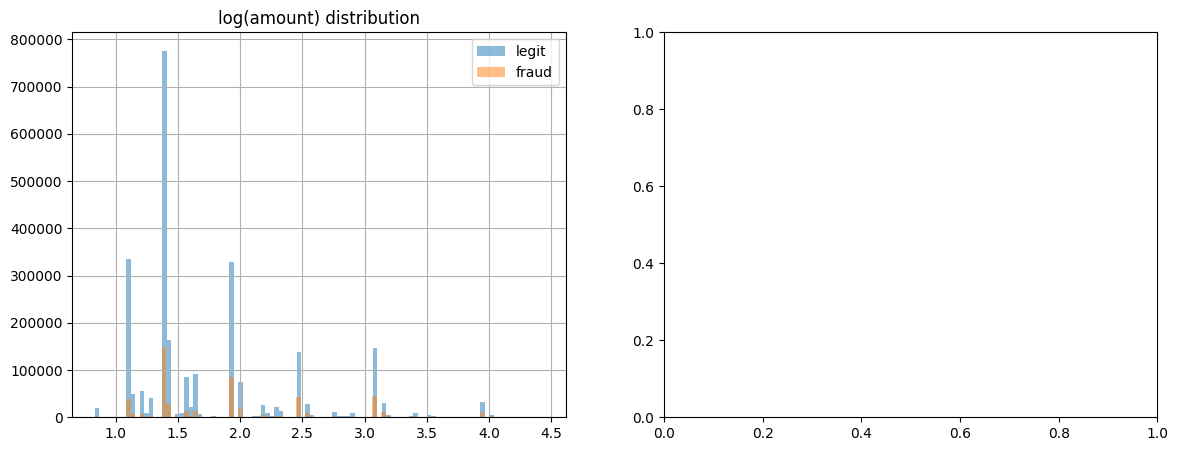

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale histogram
merged[merged['is_fraud']==0]['amount'].apply(np.log1p).hist(
    bins=100, alpha=0.5, label='legit', ax=axes[0])
merged[merged['is_fraud']==1]['amount'].apply(np.log1p).hist(
    bins=100, alpha=0.5, label='fraud', ax=axes[0])
axes[0].legend()
axes[0].set_title('log(amount) distribution')

# Характерні суми
print("Common fraud amounts:")
print(merged[merged['is_fraud']==1]['amount'].value_counts().head(20))
print("\nCommon legit amounts:")
print(merged[merged['is_fraud']==0]['amount'].value_counts().head(20))

In [ ]:
merged.groupby('error_group')['is_fraud'].mean().sort_values(ascending=False)
tx_type_pivot = pd.crosstab(
    merged['transaction_type'],
    merged['is_fraud'],
    normalize='columns'
)
print(tx_type_pivot)

is_fraud                 0         1
transaction_type                    
apple-pay         0.064935  0.052855
card_init         0.235674  0.242552
card_recurring    0.531772  0.567154
google-pay        0.138029  0.097353
resign            0.029590  0.040086


## Anomaly Detection

# EDA — Transaction Data

In [ ]:
t_per_yser = df_transaction.groupby("id_user").size()
t_per_yser.describe()

In [ ]:
t_with_label = df_transaction.merge(
    df_user[['id_user', 'is_fraud']], on='id_user'
)
t_with_label

In [ ]:
t_with_label[t_with_label['is_fraud'] == 1]["card_country"].describe()